# Метаболизм после COVID-19: динамика за 24 месяца по штаммам

Цель работы — оценить, как изменяются **метаболические показатели** от острого периода COVID-19
до контроля **через 24 месяца**, различается ли эта динамика между **штаммами вируса
(Ухань / Дельта / Омикрон)**, и как метаболические сдвиги (вместе с тяжестью поражения лёгких по КТ)
связаны с **поздними осложнениями**.

Рассматриваются восемь показателей, измеренные дважды — **во время заболевания** и **через 24 месяца**:

| Показатель | Что отражает |
|---|---|
| **НОМА-IR** | инсулинорезистентность |
| **ИМТ** | масса тела |
| **Глюкоза** | углеводный обмен |
| **АЛТ, АСТ** | функция печени / цитолиз |
| **ТГ (триглицериды)** | липидный обмен |
| **Холестерин** | липидный обмен |
| **Фибриноген** | воспаление / гемостаз |

**Структура анализа**

- **Этап 1.** Динамика каждого показателя «болезнь → 24 месяца» отдельно по штаммам
  (парные сравнения), различия динамики между штаммами и сводный график НОМА-IR (одна картинка).
- **Этап 2.** Связь метаболических **изменений** с конкретными поздними осложнениями.
- **Этап 3.** Предикторы осложнений по метаболическим показателям острого периода и КТ —
  **логистическая регрессия** и **случайный лес** (random forest) с кросс-валидацией.
- **Этап 4.** Зависимость метаболических признаков и КТ с осложнениями **по каждому штамму отдельно**,
  включая **случайный лес по каждому штамму** — что влияло на осложнение при данном варианте вируса.

> **Источник данных.** `data_v3.xlsx`, листы `УХАНЬ` (213), `ДЕЛЬТА` (272), `ОМИКРОН` (270) — всего 755
> пациентов. Показатели «через 24 месяца» — новый блок столбцов (`НОМА-IR ч/з 24 месяца`, `ИМТ ч/з 2 г`,
> `глюкоза(позд)`, `АЛТ(позд)`, `АСТ(позд)`, `ТГ(позд)`, `холестерин(позд)`, `Фибрин(позд)`).
>
> **Термины.** *OR (odds ratio)* — отношение шансов: во сколько раз выше шанс осложнения при росте
> признака. *Δ* — изменение показателя за 24 месяца (значение через 24 мес − значение в остром периоде);
> Δ > 0 — показатель вырос. Парные сравнения внутри штамма — критерий Вилкоксона; сравнение динамики
> между штаммами — критерий Краскела–Уоллиса.


## 0.1 Подготовка окружения

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
RANDOM_STATE = 42

# единые цвета штаммов
STRAIN_COLORS = {'УХАНЬ': '#4C72B0', 'ДЕЛЬТА': '#DD8452', 'ОМИКРОН': '#55A868'}
STRAINS = ['УХАНЬ', 'ДЕЛЬТА', 'ОМИКРОН']
print('Окружение готово')

Окружение готово


## 0.2 Загрузка данных и формирование переменных

Объединяем три листа по штаммам в общую выборку (755 пациентов) с меткой штамма. Для каждого из
восьми показателей формируем пару значений: **баз** — во время заболевания (максимум / при выписке —
пик выраженности острого периода) и **24м** — контроль через 24 месяца, а также **Δ = 24м − баз**.

Два показателя содержат единичные ошибочные выбросы (холестерин `3696`, глюкоза острого периода `113`),
которые ограничиваем сверху клинически правдоподобным порогом (холестерин ≤ 15 ммоль/л, глюкоза ≤ 30 ммоль/л);
на ранговые критерии это не влияет, но защищает регрессии и графики.

In [2]:
FILE_PATH = 'data_v3.xlsx'
G = pd.concat(
    [pd.read_excel(FILE_PATH, sheet_name=s, header=0).assign(Штамм=s) for s in STRAINS],
    ignore_index=True,
)
G['Штамм'] = pd.Categorical(G['Штамм'], categories=STRAINS, ordered=False)
N = len(G)
print(f'Загружено: {N} пациентов ({", ".join(f"{s}={int((G.Штамм==s).sum())}" for s in STRAINS)})')

def num(i):
    """Числовой столбец по позиционному индексу."""
    return pd.to_numeric(G.iloc[:, i], errors='coerce')

def binz(i):
    """Бинаризация осложнения: >0 -> 1."""
    return (num(i).fillna(0) > 0).astype(int)

# --- 8 метаболических показателей: (индекс_баз, индекс_24м, верхний_клип, единицы) ---
MARKERS = {
    'НОМА-IR':    (114, 163, None, ''),
    'ИМТ':        ( 31, 164, None, 'кг/м²'),
    'Глюкоза':    ( 66, 162, 30.0, 'ммоль/л'),
    'АЛТ':        ( 64, 152, None, 'Ед/л'),
    'АСТ':        ( 65, 153, None, 'Ед/л'),
    'ТГ':         ( 69, 157, None, 'ммоль/л'),
    'Холестерин': ( 70, 156, 15.0, 'ммоль/л'),
    'Фибриноген': ( 79, 160, None, 'г/л'),
}

# матрицы баз / 24м / Δ
base = pd.DataFrame({m: (num(b).clip(upper=c) if c else num(b)) for m, (b, l, c, u) in MARKERS.items()})
late = pd.DataFrame({m: (num(l).clip(upper=c) if c else num(l)) for m, (b, l, c, u) in MARKERS.items()})
delta = late - base

# --- поздние осложнения (idx -> подпись) ---
COMP_IDX = {
    142: 'Пневмофиброз',
    140: 'Повторные пневмонии',
    143: 'ХОБЛ / бр. астма',
    144: 'ЖКТ / НЖБП',
    134: 'СД / эндокринные',
    130: 'ССЗ (новые)',
    132: 'Операции на венах',
    141: 'ОНМК / ИМ',
    135: 'Зрение / слух',
    136: 'Психика / ЦНС / обоняние',
}
comp = pd.DataFrame({name: binz(i) for i, name in COMP_IDX.items()})
comp['Штамм'] = G['Штамм'].values

print('Показателей:', len(MARKERS), '| Осложнений:', len(COMP_IDX))
print('Событий (осложнения):')
display(comp.drop(columns='Штамм').sum().sort_values(ascending=False).to_frame('n'))

Загружено: 755 пациентов (УХАНЬ=213, ДЕЛЬТА=272, ОМИКРОН=270)
Показателей: 8 | Осложнений: 10
Событий (осложнения):


,n
ЖКТ / НЖБП,191
Повторные пневмонии,171
Зрение / слух,147
ССЗ (новые),111
Психика / ЦНС / обоняние,78
Операции на венах,52
СД / эндокринные,38
Пневмофиброз,35
ОНМК / ИМ,26
ХОБЛ / бр. астма,24


## 0.3 Характеристика групп по штаммам

Штаммы различаются по возрасту, полу, охвату вакцинацией и тяжести поражения лёгких (КТ) — это важно
помнить при интерпретации: часть различий в динамике может объясняться не самим штаммом, а составом групп.

In [3]:
overview = pd.DataFrame({
    'n':               [int((G.Штамм == s).sum()) for s in STRAINS],
    'Возраст, медиана':[num(2)[G.Штамм == s].median() for s in STRAINS],
    'Женщины, %':      [100 * (num(3)[G.Штамм == s] == 2).mean() for s in STRAINS],
    'Вакцинированы, %':[100 * (num(10)[G.Штамм == s].fillna(0) > 0).mean() for s in STRAINS],
    'КТ(ИТОГ), медиана':[num(38)[G.Штамм == s].median() for s in STRAINS],
    'КТ%макс, медиана':[num(39)[G.Штамм == s].median() for s in STRAINS],
}, index=STRAINS)
display(overview.round(1))
print('Женщины кодируются как «2» в столбце «пол».')

,n,"Возраст, медиана","Женщины, %","Вакцинированы, %","КТ(ИТОГ), медиана","КТ%макс, медиана"
УХАНЬ,213,38.000,18.800,0.500,1.000,10.000
ДЕЛЬТА,272,41.000,41.500,29.800,1.000,16.000
ОМИКРОН,270,36.000,57.800,89.300,0.000,0.000


Женщины кодируются как «2» в столбце «пол».


---
# Этап 1. Динамика метаболизма: болезнь → 24 месяца, по штаммам

Для каждого показателя сравниваем значение острого периода и значение через 24 месяца **внутри каждого
штамма** (парный критерий Вилкоксона), приводим медианы и медианное изменение Δ.

## 1.1 Сводная таблица динамики

In [4]:
def wilcox_p(a, b):
    pair = pd.DataFrame({'a': a, 'b': b}).dropna()
    if len(pair) < 10 or (pair['a'] == pair['b']).all():
        return np.nan, len(pair)
    return stats.wilcoxon(pair['a'], pair['b']).pvalue, len(pair)

rows = []
for m in MARKERS:
    for s in STRAINS + ['ВСЕ']:
        mask = (G.Штамм == s).values if s != 'ВСЕ' else np.ones(N, dtype=bool)
        b, l = base[m][mask], late[m][mask]
        d = (l - b)
        p, n = wilcox_p(b, l)
        rows.append({'Показатель': m, 'Штамм': s, 'n': n,
                     'Медиана баз': b.median(), 'Медиана 24м': l.median(),
                     'Δ медиана': d.median(), 'p (Вилкоксон)': p})
dyn = pd.DataFrame(rows)

# компактная широкая таблица Δ-медиан + значимость
def star(p):
    return '' if pd.isna(p) else ('***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'н.з.')
wide = dyn.copy()
wide['Δ (p)'] = wide.apply(lambda r: f"{r['Δ медиана']:+.2f} {star(r['p (Вилкоксон)'])}", axis=1)
tab = wide.pivot(index='Показатель', columns='Штамм', values='Δ (p)').reindex(index=list(MARKERS), columns=STRAINS + ['ВСЕ'])
print('Δ медиана (24м − баз); *** p<0.001, ** p<0.01, * p<0.05, н.з. — не значимо')
display(tab)
display(dyn.round(3))

Δ медиана (24м − баз); *** p<0.001, ** p<0.01, * p<0.05, н.з. — не значимо


Штамм,УХАНЬ,ДЕЛЬТА,ОМИКРОН,ВСЕ
Показатель,,,,
НОМА-IR,+0.33 ***,+0.23 ***,+0.12 ***,+0.21 ***
ИМТ,+0.10 н.з.,+0.02 н.з.,+0.06 н.з.,+0.04 *
Глюкоза,-0.30 ***,-0.46 ***,+0.00 н.з.,-0.22 ***
АЛТ,-27.70 ***,-30.70 ***,-15.75 ***,-24.85 ***
АСТ,-10.10 ***,-11.90 ***,-6.70 ***,-9.30 ***
ТГ,+0.41 ***,+0.37 ***,+0.03 н.з.,+0.20 ***
Холестерин,+0.05 н.з.,+0.08 н.з.,+0.12 *,+0.10 *
Фибриноген,-1.13 ***,-1.13 ***,-0.73 ***,-0.99 ***


,Показатель,Штамм,n,Медиана баз,Медиана 24м,Δ медиана,p (Вилкоксон)
0,НОМА-IR,УХАНЬ,213,1.130,1.560,0.330,0.000
1,НОМА-IR,ДЕЛЬТА,271,1.550,2.100,0.230,0.000
2,НОМА-IR,ОМИКРОН,268,1.300,1.715,0.120,0.000
3,НОМА-IR,ВСЕ,752,1.350,1.800,0.210,0.000
4,ИМТ,УХАНЬ,213,26.200,26.240,0.100,0.068
5,ИМТ,ДЕЛЬТА,269,27.800,27.760,0.020,0.250
6,ИМТ,ОМИКРОН,268,26.600,26.470,0.055,0.132
7,ИМТ,ВСЕ,750,26.900,27.020,0.040,0.011
8,Глюкоза,УХАНЬ,213,5.660,5.400,-0.300,0.000
9,Глюкоза,ДЕЛЬТА,271,5.955,5.590,-0.460,0.000


## 1.2 Графики: значения в остром периоде vs через 24 месяца

Для каждого показателя — распределение значений «во время заболевания» и «через 24 месяца»
внутри каждого штамма (парные боксплоты).

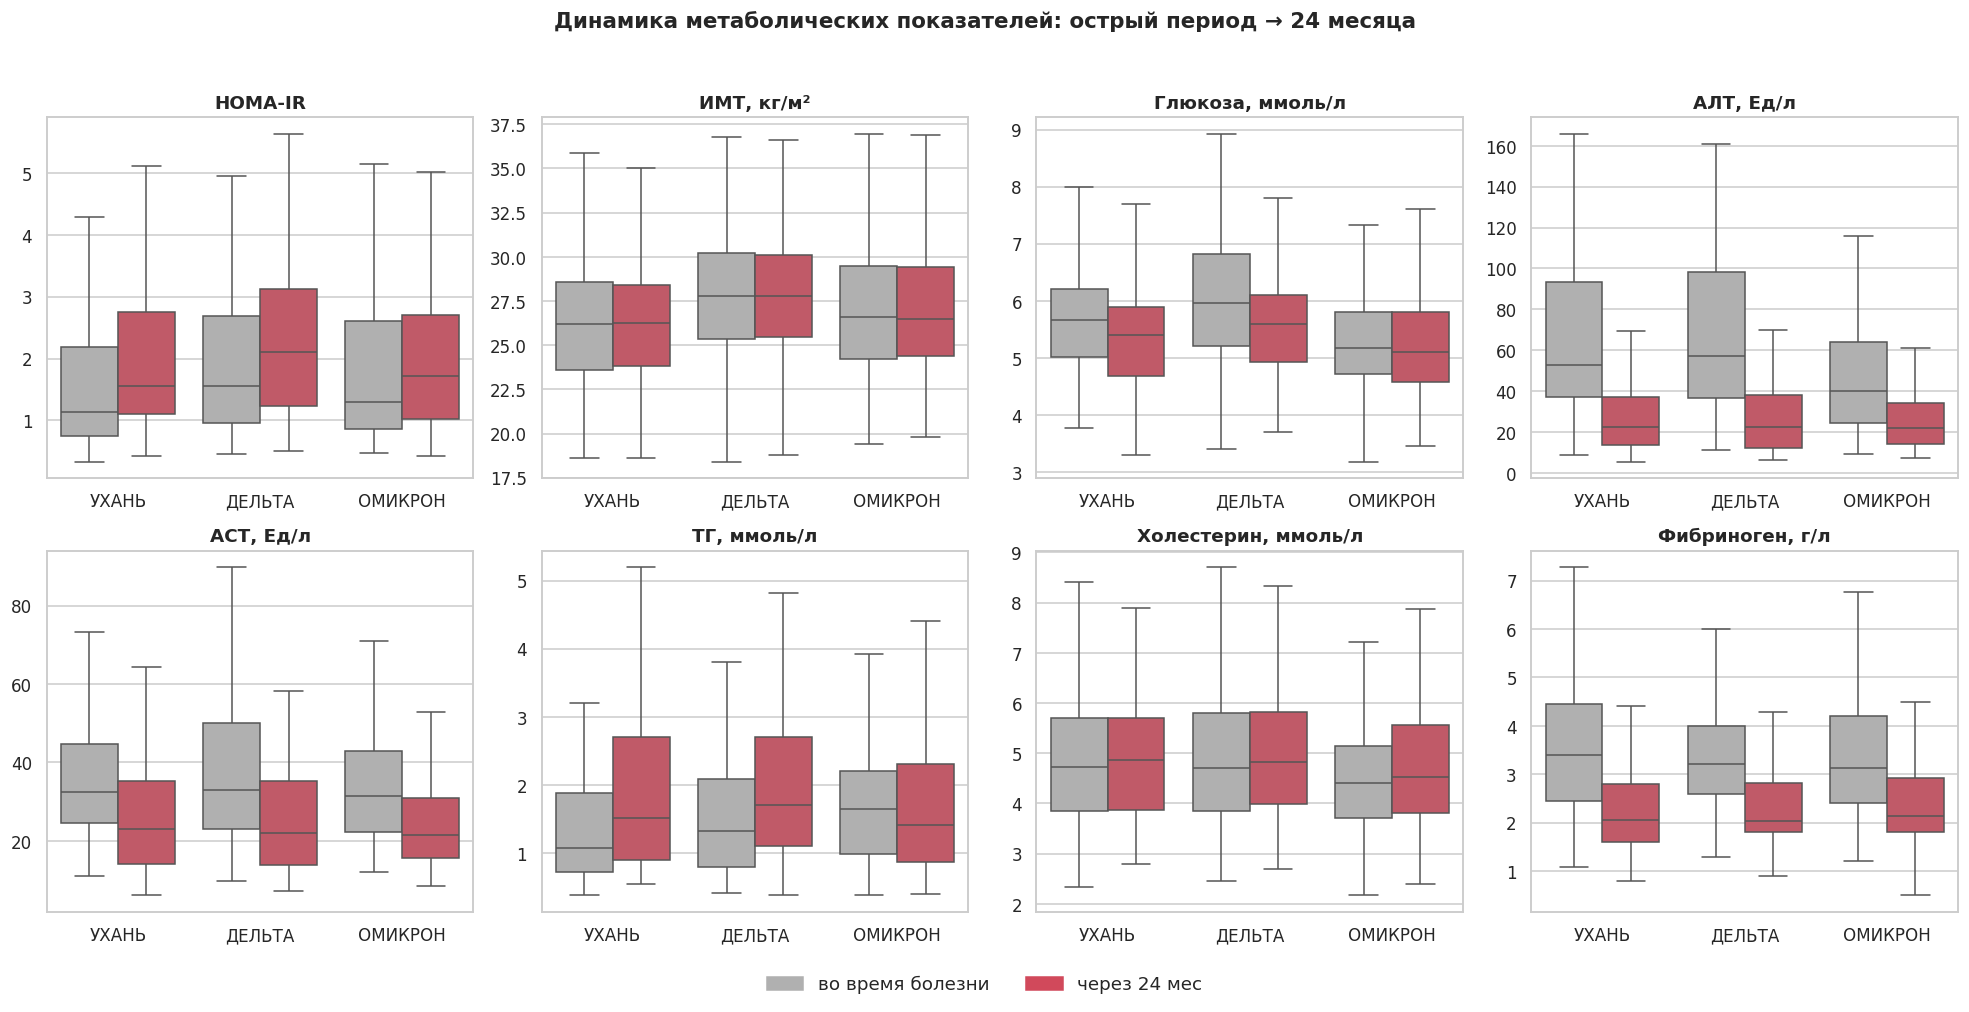

In [5]:
long = []
for m in MARKERS:
    for s in STRAINS:
        mask = (G.Штамм == s).values
        for tp, series in [('во время\nболезни', base[m][mask]), ('через\n24 мес', late[m][mask])]:
            for v in series.dropna():
                long.append({'Показатель': m, 'Штамм': s, 'Период': tp, 'Значение': v})
long = pd.DataFrame(long)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, m in zip(axes.ravel(), MARKERS):
    sub = long[long['Показатель'] == m]
    sns.boxplot(data=sub, x='Штамм', y='Значение', hue='Период', ax=ax,
                showfliers=False, palette=['#B0B0B0', '#D1495B'], order=STRAINS)
    ax.set_title(f'{m}' + (f', {MARKERS[m][3]}' if MARKERS[m][3] else ''), fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.legend_.remove() if ax.get_legend() else None
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['#B0B0B0', '#D1495B']]
fig.suptitle('Динамика метаболических показателей: острый период → 24 месяца', y=1.00, fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
fig.legend(handles, ['во время болезни', 'через 24 мес'], loc='lower center', ncol=2,
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.01))
plt.show()

## 1.3 Различие динамики между штаммами

Сравниваем **изменение Δ** между тремя штаммами (критерий Краскела–Уоллиса) и оцениваем эффект штамма
на Δ **медианной (квантильной) регрессией** `Δ ~ штамм`, дополнительно с поправкой на исходную тяжесть
(КТ%макс) и возраст.

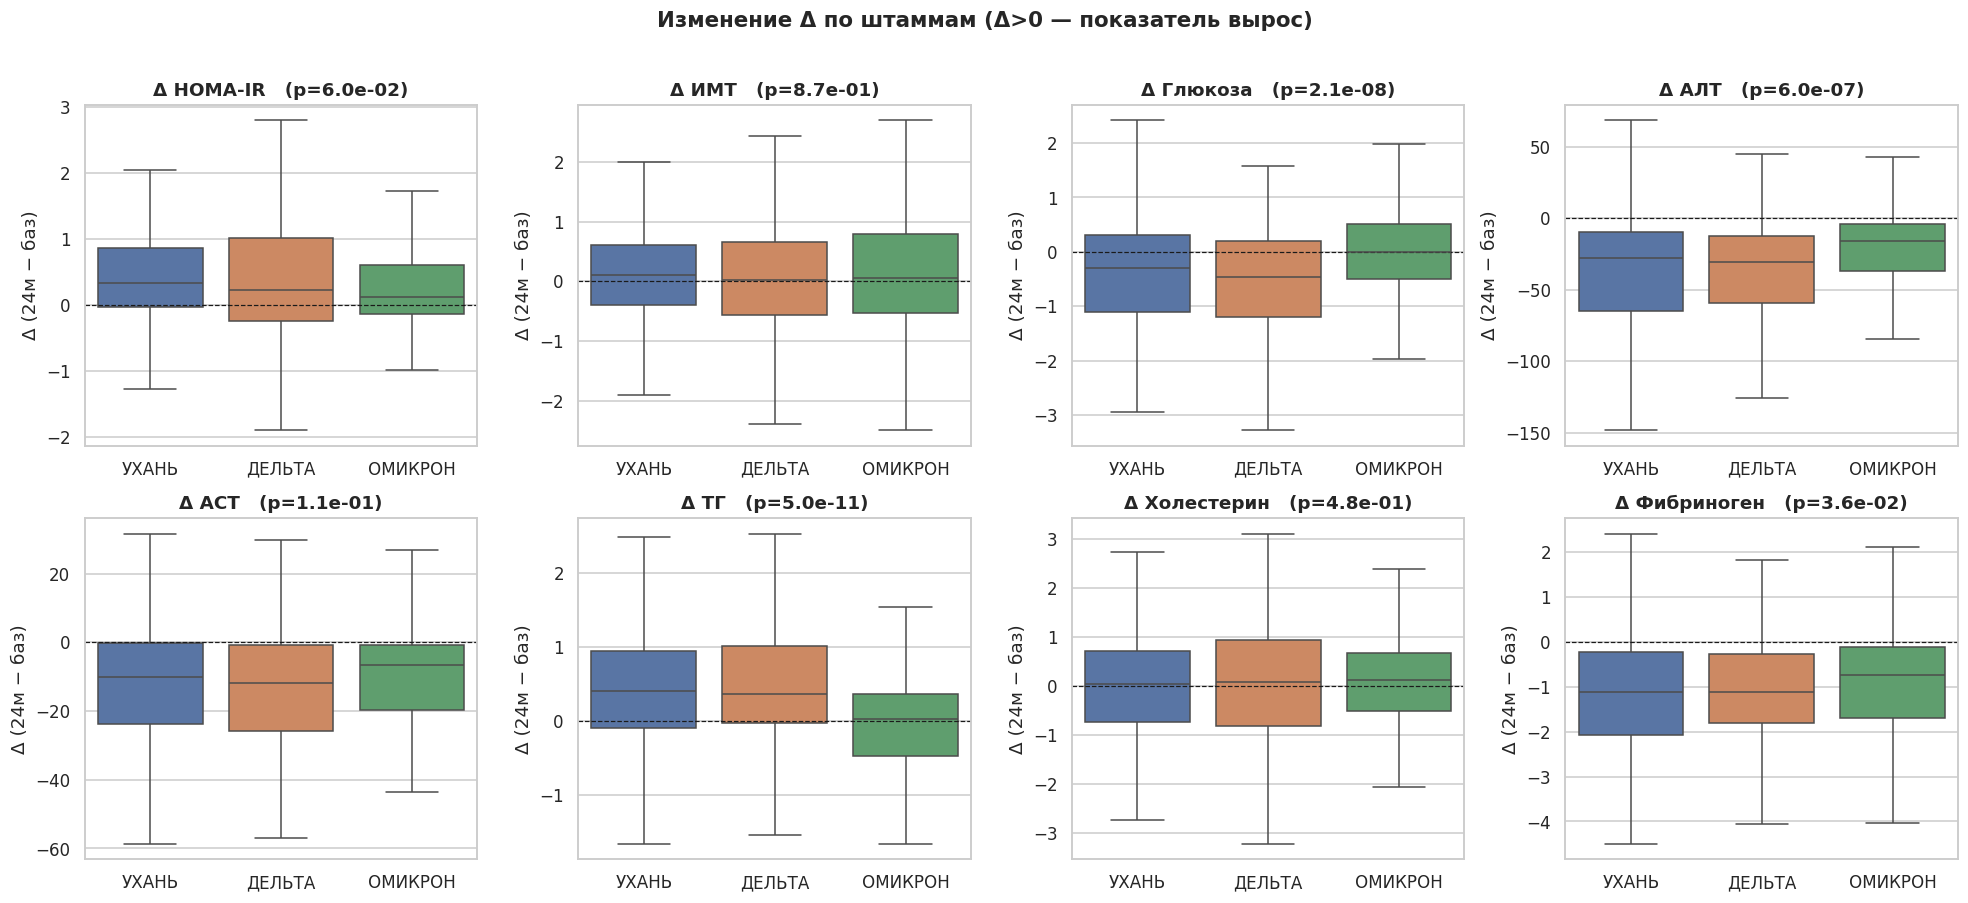

Краскел–Уоллис: сравнение Δ между штаммами


,Δ Ухань,Δ Дельта,Δ Омикрон,Kruskal p
Показатель,,,,
НОМА-IR,0.330,0.230,0.120,0.060
ИМТ,0.100,0.020,0.055,0.869
Глюкоза,-0.300,-0.460,0.000,0.000
АЛТ,-27.700,-30.700,-15.750,0.000
АСТ,-10.100,-11.900,-6.700,0.109
ТГ,0.410,0.370,0.025,0.000
Холестерин,0.050,0.080,0.125,0.483
Фибриноген,-1.130,-1.130,-0.735,0.036


In [6]:
# Δ по штаммам — боксплоты + Kruskal
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
kruskal_rows = []
for ax, m in zip(axes.ravel(), MARKERS):
    d = delta[m]
    groups = [d[(G.Штамм == s).values].dropna() for s in STRAINS]
    h, p = stats.kruskal(*groups)
    kruskal_rows.append({'Показатель': m, 'Δ Ухань': groups[0].median(), 'Δ Дельта': groups[1].median(),
                         'Δ Омикрон': groups[2].median(), 'Kruskal p': p})
    sns.boxplot(x=G.Штамм.values, y=d.values, ax=ax, showfliers=False,
                palette=STRAIN_COLORS, order=STRAINS)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title(f'Δ {m}   (p={p:.1e})', fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('Δ (24м − баз)')
fig.suptitle('Изменение Δ по штаммам (Δ>0 — показатель вырос)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Краскел–Уоллис: сравнение Δ между штаммами')
display(pd.DataFrame(kruskal_rows).set_index('Показатель').round(3))

In [7]:
# Квантильная (медианная) регрессия Δ ~ штамм (+ КТ%макс, возраст). Ухань — референс.
qrows = []
kt = num(39); age = num(2)
for m in MARKERS:
    reg = pd.DataFrame({'d': delta[m], 'Штамм': G.Штамм.values,
                        'KT': kt, 'age': age}).dropna()
    try:
        fit = smf.quantreg('d ~ C(Штамм, Treatment(reference="УХАНЬ")) + KT + age', reg).fit(q=0.5)
        for key, lab in [('C(Штамм, Treatment(reference="УХАНЬ"))[T.ДЕЛЬТА]', 'Дельта vs Ухань'),
                         ('C(Штамм, Treatment(reference="УХАНЬ"))[T.ОМИКРОН]', 'Омикрон vs Ухань')]:
            qrows.append({'Показатель': m, 'Контраст': lab,
                          'Δ-сдвиг медианы': fit.params[key], 'p': fit.pvalues[key]})
    except Exception as e:
        qrows.append({'Показатель': m, 'Контраст': 'ошибка', 'Δ-сдвиг медианы': np.nan, 'p': np.nan})
qtab = pd.DataFrame(qrows)
print('Медианная регрессия Δ ~ штамм (поправка на КТ%макс и возраст); референс — Ухань.')
print('Отрицательный сдвиг = у штамма прирост показателя меньше, чем у Ухани.')
display(qtab.pivot(index='Показатель', columns='Контраст', values='Δ-сдвиг медианы')
        .reindex(index=list(MARKERS)).round(3))
display(qtab.round(4))

Медианная регрессия Δ ~ штамм (поправка на КТ%макс и возраст); референс — Ухань.
Отрицательный сдвиг = у штамма прирост показателя меньше, чем у Ухани.


/home/user/code/covid_an/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Контраст,Дельта vs Ухань,Омикрон vs Ухань
Показатель,,
НОМА-IR,-0.109,-0.195
ИМТ,-0.042,-0.017
Глюкоза,-0.142,0.268
АЛТ,2.711,12.393
АСТ,-2.239,1.831
ТГ,-0.000,-0.297
Холестерин,-0.024,0.129
Фибриноген,0.164,0.336


,Показатель,Контраст,Δ-сдвиг медианы,p
0,НОМА-IR,Дельта vs Ухань,-0.109,0.147
1,НОМА-IR,Омикрон vs Ухань,-0.195,0.009
2,ИМТ,Дельта vs Ухань,-0.042,0.654
3,ИМТ,Омикрон vs Ухань,-0.017,0.858
4,Глюкоза,Дельта vs Ухань,-0.142,0.189
5,Глюкоза,Омикрон vs Ухань,0.268,0.013
6,АЛТ,Дельта vs Ухань,2.711,0.412
7,АЛТ,Омикрон vs Ухань,12.393,0.000
8,АСТ,Дельта vs Ухань,-2.239,0.208
9,АСТ,Омикрон vs Ухань,1.831,0.303


## 1.4 Изменение НОМА-IR за 24 месяца по штаммам (одна картинка)

Ключевой показатель инсулинорезистентности НОМА-IR на одном графике: медиана в остром периоде и через
24 месяца, отдельная линия для каждого штамма. Планки — 95% доверительный интервал медианы (бутстрэп);
подпись справа — медианное изменение Δ и его значимость.

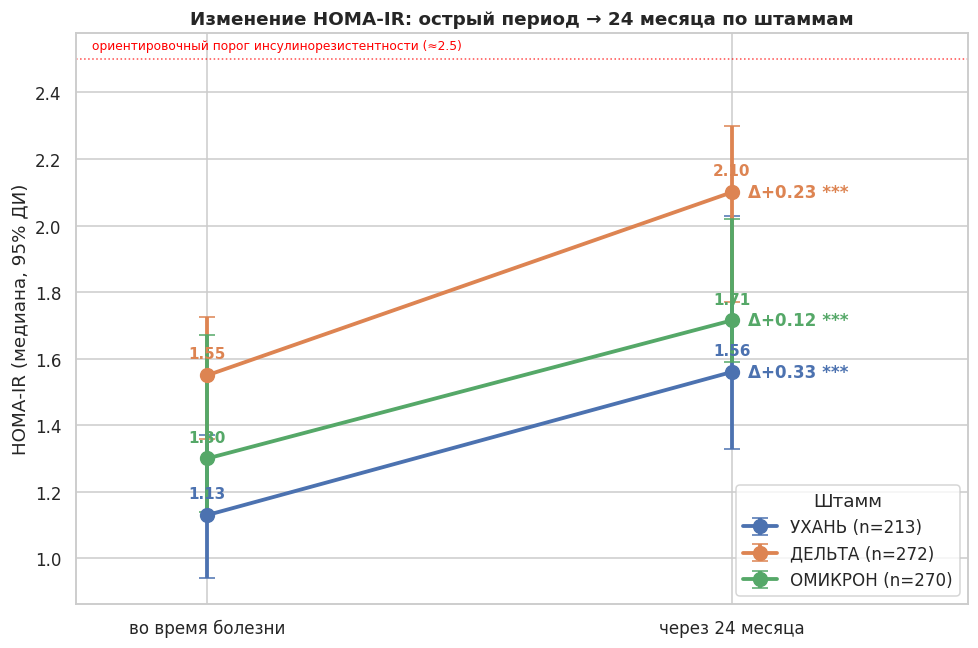

In [8]:
rng = np.random.default_rng(RANDOM_STATE)

def med_ci(v, nboot=2000):
    v = pd.Series(v).dropna().values
    if len(v) < 5:
        return np.nan, np.nan, np.nan
    boot = np.median(rng.choice(v, size=(nboot, len(v)), replace=True), axis=1)
    return np.median(v), np.percentile(boot, 2.5), np.percentile(boot, 97.5)

fig, ax = plt.subplots(figsize=(9, 6))
xpos = [0, 1]
for s in STRAINS:
    mask = (G.Штамм == s).values
    tp = [med_ci(base['НОМА-IR'][mask]), med_ci(late['НОМА-IR'][mask])]
    meds = [t[0] for t in tp]
    lo = [t[0] - t[1] for t in tp]; hi = [t[2] - t[0] for t in tp]
    ax.errorbar(xpos, meds, yerr=[lo, hi], color=STRAIN_COLORS[s], marker='o', ms=9, lw=2.5,
                capsize=5, label=f'{s} (n={int(mask.sum())})')
    for x, m in zip(xpos, meds):
        ax.annotate(f'{m:.2f}', (x, m), textcoords='offset points', xytext=(0, 11),
                    ha='center', color=STRAIN_COLORS[s], fontweight='bold', fontsize=10)
    p, _ = wilcox_p(base['НОМА-IR'][mask], late['НОМА-IR'][mask])
    dmed = (late['НОМА-IR'][mask] - base['НОМА-IR'][mask]).median()
    ax.annotate(f'Δ{dmed:+.2f} {star(p)}', (1.03, meds[1]), color=STRAIN_COLORS[s],
                fontsize=11, va='center', fontweight='bold')
ax.axhline(2.5, color='red', ls=':', lw=1, alpha=0.7)
ax.annotate('ориентировочный порог инсулинорезистентности (≈2.5)', (-0.22, 2.52),
            fontsize=8, color='red', va='bottom')
ax.set_xticks(xpos); ax.set_xticklabels(['во время болезни', 'через 24 месяца'], fontsize=11)
ax.set_xlim(-0.25, 1.45); ax.set_ylabel('НОМА-IR (медиана, 95% ДИ)')
ax.set_title('Изменение НОМА-IR: острый период → 24 месяца по штаммам', fontweight='bold')
ax.legend(title='Штамм', loc='lower right'); plt.tight_layout(); plt.show()

**Как читать этап 1.** Показатели острого воспаления и цитолиза (**АЛТ, АСТ, фибриноген**, отчасти
**глюкоза**) через 24 месяца снижаются — это ожидаемое восстановление после острой фазы. Напротив,
маркеры обмена — **НОМА-IR** (инсулинорезистентность) и **ТГ** (триглицериды) — за 24 месяца **растут**,
то есть формируется отсроченный метаболический сдвиг. По штаммам прирост НОМА-IR, ТГ и глюкозы наименее
выражен у **Омикрона** (что подтверждают Краскел–Уоллис и медианная регрессия с поправкой на тяжесть и возраст).

---
# Этап 2. Метаболические изменения и поздние осложнения

Проверяем, связано ли **изменение** каждого метаболического показателя за 24 месяца с наличием того или
иного позднего осложнения. Для каждой пары «показатель Δ × осложнение» сравниваем Δ у пациентов с
осложнением и без (критерий Манна–Уитни), эффект выражаем ранговой бисериальной корреляцией *r*
(от −1 до +1; r>0 — при осложнении показатель растёт сильнее). Множественность контролируем поправкой
Бенджамини–Хохберга (FDR).

## 2.1 Карта связей «изменение показателя ↔ осложнение»

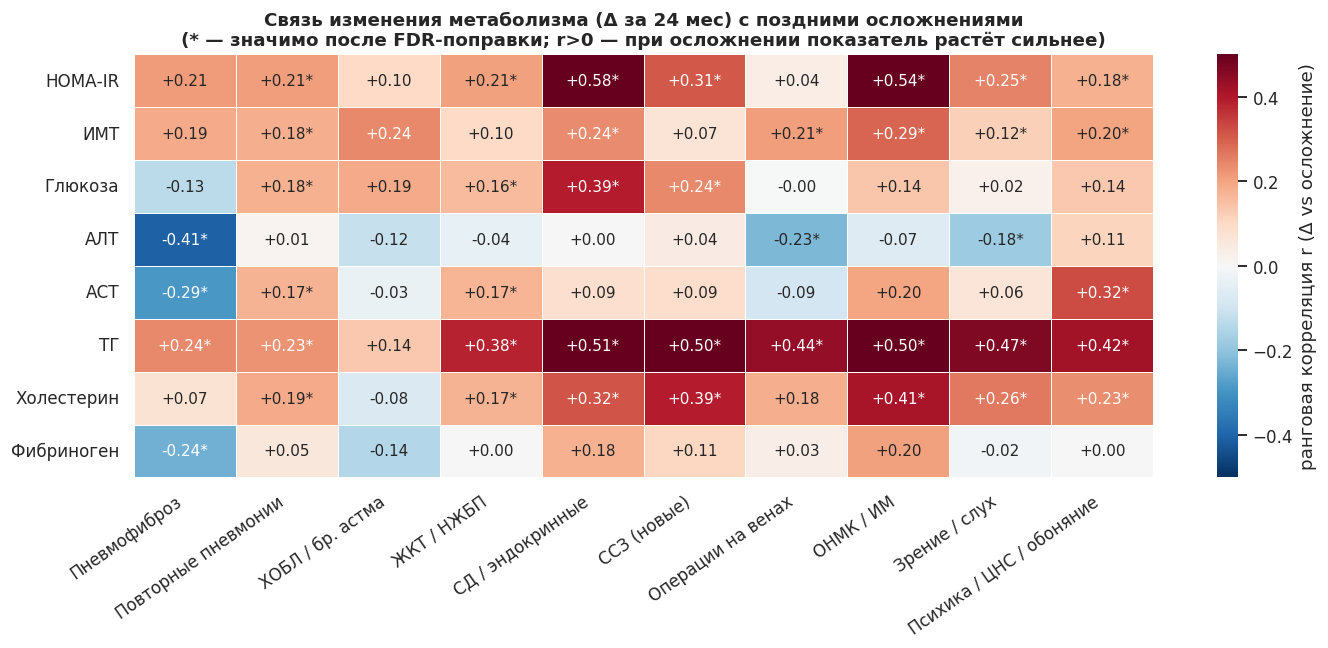

In [9]:
def rank_biserial(x, y):
    """r и p Манна–Уитни для непрерывного x по бинарному y (1 vs 0)."""
    g = pd.DataFrame({'x': x, 'y': y}).dropna()
    a, b = g[g.y == 1]['x'], g[g.y == 0]['x']
    if len(a) < 8 or len(b) < 8:
        return np.nan, np.nan, len(a)
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 2 * u / (len(a) * len(b)) - 1          # rank-biserial correlation
    return r, p, len(a)

comp_names = list(COMP_IDX.values())
R = pd.DataFrame(index=list(MARKERS), columns=comp_names, dtype=float)
P = pd.DataFrame(index=list(MARKERS), columns=comp_names, dtype=float)
for m in MARKERS:
    for cn in comp_names:
        r, p, na = rank_biserial(delta[m], comp[cn])
        R.loc[m, cn] = r; P.loc[m, cn] = p

# FDR по всем валидным p
flat = P.values.flatten(); ok = ~np.isnan(flat)
q = np.full_like(flat, np.nan); q[ok] = multipletests(flat[ok], method='fdr_bh')[1]
Q = pd.DataFrame(q.reshape(P.shape), index=P.index, columns=P.columns)

annot = R.copy().astype(object)
for m in R.index:
    for cn in R.columns:
        r, qq = R.loc[m, cn], Q.loc[m, cn]
        annot.loc[m, cn] = '' if pd.isna(r) else f"{r:+.2f}" + ('*' if qq < 0.05 else '')

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(R.astype(float), annot=annot.values, fmt='', cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            linewidths=0.5, cbar_kws={'label': 'ранговая корреляция r (Δ vs осложнение)'}, ax=ax)
ax.set_title('Связь изменения метаболизма (Δ за 24 мес) с поздними осложнениями\n'
             '(* — значимо после FDR-поправки; r>0 — при осложнении показатель растёт сильнее)',
             fontweight='bold')
plt.xticks(rotation=35, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

## 2.2 Детализация по ключевым осложнениям

In [10]:
focus = ['ССЗ (новые)', 'ОНМК / ИМ', 'СД / эндокринные', 'Операции на венах',
         'Повторные пневмонии', 'Зрение / слух', 'ЖКТ / НЖБП']
det = []
for cn in focus:
    for m in MARKERS:
        g = pd.DataFrame({'d': delta[m], 'y': comp[cn]}).dropna()
        a, b = g[g.y == 1]['d'], g[g.y == 0]['d']
        if len(a) < 8:
            continue
        _, p = stats.mannwhitneyu(a, b)
        det.append({'Осложнение': cn, 'Показатель': m, 'Δ при осложнении': a.median(),
                    'Δ без': b.median(), 'p': p})
det = pd.DataFrame(det)
det['q (FDR)'] = multipletests(det['p'], method='fdr_bh')[1]
# показываем только устойчивые связи
sig = det[det['q (FDR)'] < 0.05].sort_values(['Осложнение', 'q (FDR)'])
print('Значимые связи (FDR<0.05): изменение метаболизма Δ при наличии осложнения vs без него')
display(sig.round(3).reset_index(drop=True))

Значимые связи (FDR<0.05): изменение метаболизма Δ при наличии осложнения vs без него


,Осложнение,Показатель,Δ при осложнении,Δ без,p,q (FDR)
0,ЖКТ / НЖБП,ТГ,0.780,0.100,0.000,0.000
1,ЖКТ / НЖБП,НОМА-IR,0.510,0.150,0.000,0.000
2,ЖКТ / НЖБП,Холестерин,0.410,0.040,0.000,0.001
3,ЖКТ / НЖБП,АСТ,-4.600,-10.500,0.000,0.001
4,ЖКТ / НЖБП,Глюкоза,-0.050,-0.300,0.001,0.003
5,Зрение / слух,ТГ,0.880,0.110,0.000,0.000
6,Зрение / слух,Холестерин,0.640,0.040,0.000,0.000
7,Зрение / слух,НОМА-IR,0.750,0.160,0.000,0.000
8,Зрение / слух,АЛТ,-41.100,-23.200,0.001,0.001
9,Зрение / слух,ИМТ,0.130,0.000,0.025,0.045


**Как читать этап 2.** Сквозные маркеры риска почти всех поздних осложнений — рост **ТГ** и
**НОМА-IR** за 24 месяца; для сосудистых исходов (ССЗ, ОНМК/ИМ, операции на венах) добавляется рост
**холестерина** и **глюкозы**. Это связи **на одном интервале** (осложнение и метаболический сдвиг
развиваются параллельно за 24 месяца), поэтому они описывают сопряжённость, а не доказанную
причинность. Прогностическую (упреждающую) оценку даёт этап 3 — по показателям острого периода.

---
# Этап 3. Предикторы осложнений: логистическая регрессия и случайный лес

Здесь предикторы — **показатели острого периода** (во время заболевания) и **тяжесть КТ**: они
измерены *раньше* осложнений, поэтому пригодны для прогноза. Сравниваем две модели — **логистическую
регрессию** и **случайный лес (random forest)** — по площади под ROC-кривой (AUC) на 5-блочной
кросс-валидации, и смотрим вклад признаков.

## 3.1 Матрица предикторов и однофакторные OR

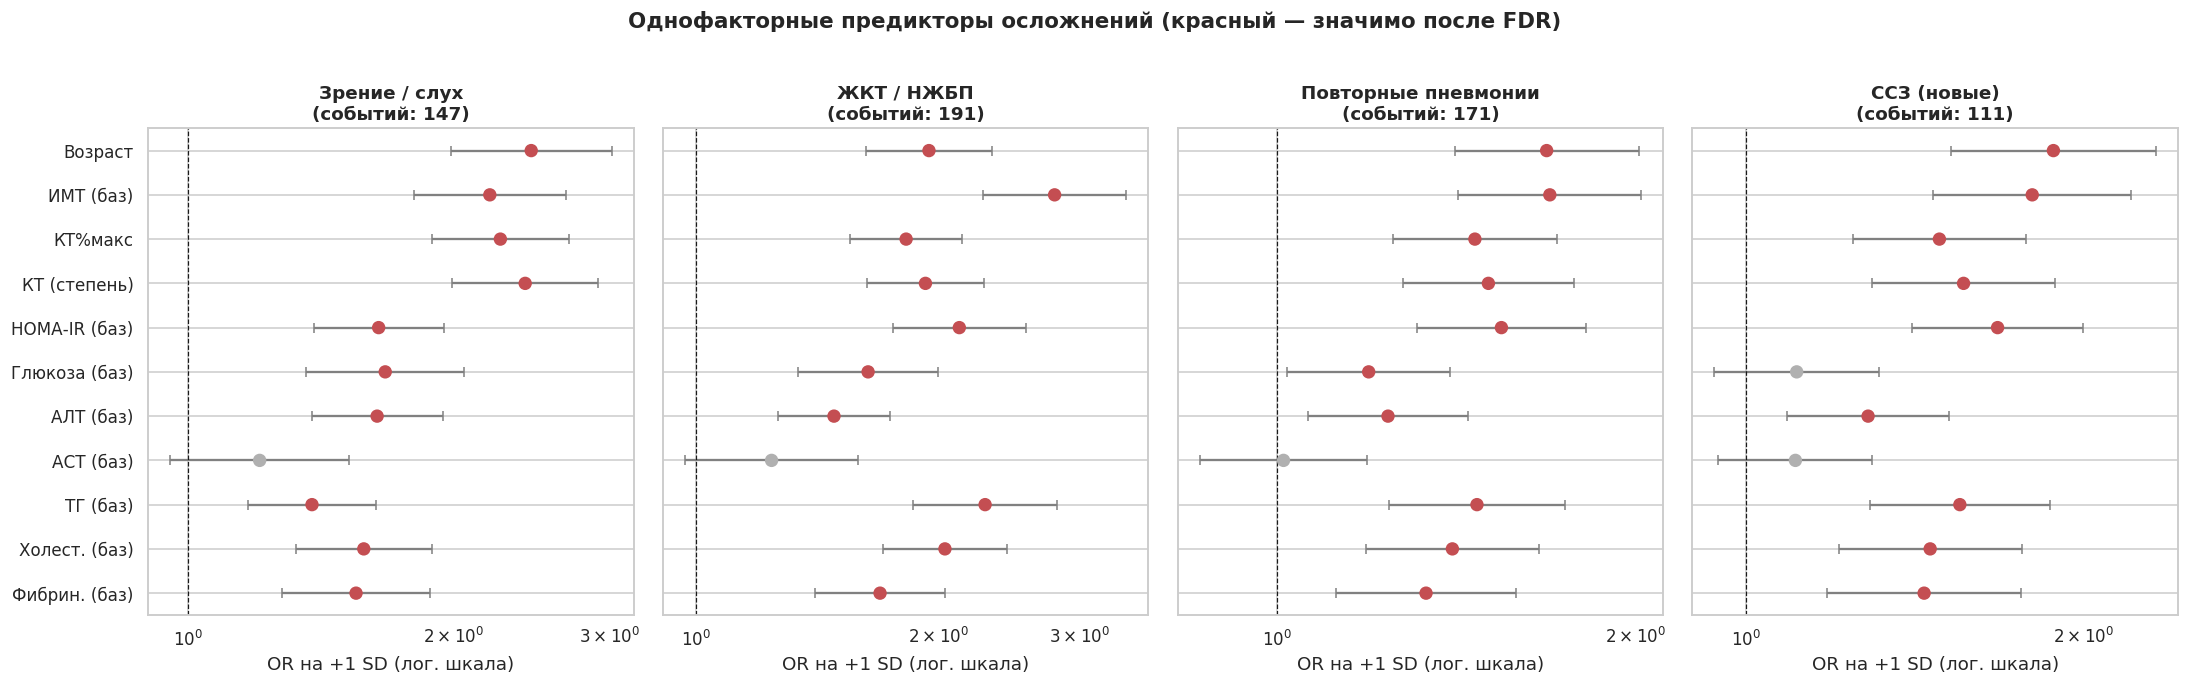

In [11]:
PRED = {
    'Возраст':       num(2),
    'ИМТ (баз)':     base['ИМТ'],
    'КТ%макс':       num(39),
    'КТ (степень)':  num(38),
    'НОМА-IR (баз)': base['НОМА-IR'],
    'Глюкоза (баз)': base['Глюкоза'],
    'АЛТ (баз)':     base['АЛТ'],
    'АСТ (баз)':     base['АСТ'],
    'ТГ (баз)':      base['ТГ'],
    'Холест. (баз)': base['Холестерин'],
    'Фибрин. (баз)': base['Фибриноген'],
}
X = pd.DataFrame(PRED)
X = X.fillna(X.median())

def or_per_sd(y, x):
    """OR на +1 стандартное отклонение (одномерная логистическая)."""
    z = (x - x.mean()) / x.std()
    m = sm.Logit(y, sm.add_constant(z)).fit(disp=0)
    return np.exp(m.params.iloc[1]), np.exp(m.conf_int().iloc[1, 0]), np.exp(m.conf_int().iloc[1, 1]), m.pvalues.iloc[1]

FREQUENT = ['Зрение / слух', 'ЖКТ / НЖБП', 'Повторные пневмонии', 'ССЗ (новые)']
or_rows = []
for cn in FREQUENT:
    y = comp[cn]
    for c in X.columns:
        orr, lo, hi, p = or_per_sd(y, X[c])
        or_rows.append({'Осложнение': cn, 'Признак': c, 'OR/SD': orr, 'lo': lo, 'hi': hi, 'p': p})
ordf = pd.DataFrame(or_rows)
ordf['q'] = ordf.groupby('Осложнение')['p'].transform(lambda s: multipletests(s, method='fdr_bh')[1])

# forest-график OR по 4 частым осложнениям
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
for ax, cn in zip(axes, FREQUENT):
    sub = ordf[ordf['Осложнение'] == cn].set_index('Признак').loc[list(X.columns)]
    ypos = np.arange(len(sub))[::-1]
    colors = ['#C44E52' if q < 0.05 else '#B0B0B0' for q in sub['q']]
    ax.errorbar(sub['OR/SD'], ypos, xerr=[sub['OR/SD'] - sub['lo'], sub['hi'] - sub['OR/SD']],
                fmt='o', color='k', ecolor='gray', capsize=3, ms=5)
    ax.scatter(sub['OR/SD'], ypos, c=colors, s=60, zorder=3)
    ax.axvline(1, color='k', ls='--', lw=0.8)
    ax.set_yticks(ypos); ax.set_yticklabels(sub.index)
    ax.set_xscale('log'); ax.set_title(f'{cn}\n(событий: {int(comp[cn].sum())})', fontweight='bold')
    ax.set_xlabel('OR на +1 SD (лог. шкала)')
fig.suptitle('Однофакторные предикторы осложнений (красный — значимо после FDR)', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3.2 Логистическая регрессия vs случайный лес (кросс-валидация)

,событий,AUC логистич.,AUC случ. лес
Осложнение,,,
Зрение / слух,147,0.783 ± 0.014,0.783 ± 0.017
ЖКТ / НЖБП,191,0.800 ± 0.011,0.811 ± 0.015
Повторные пневмонии,171,0.669 ± 0.056,0.681 ± 0.053
ССЗ (новые),111,0.703 ± 0.034,0.712 ± 0.029


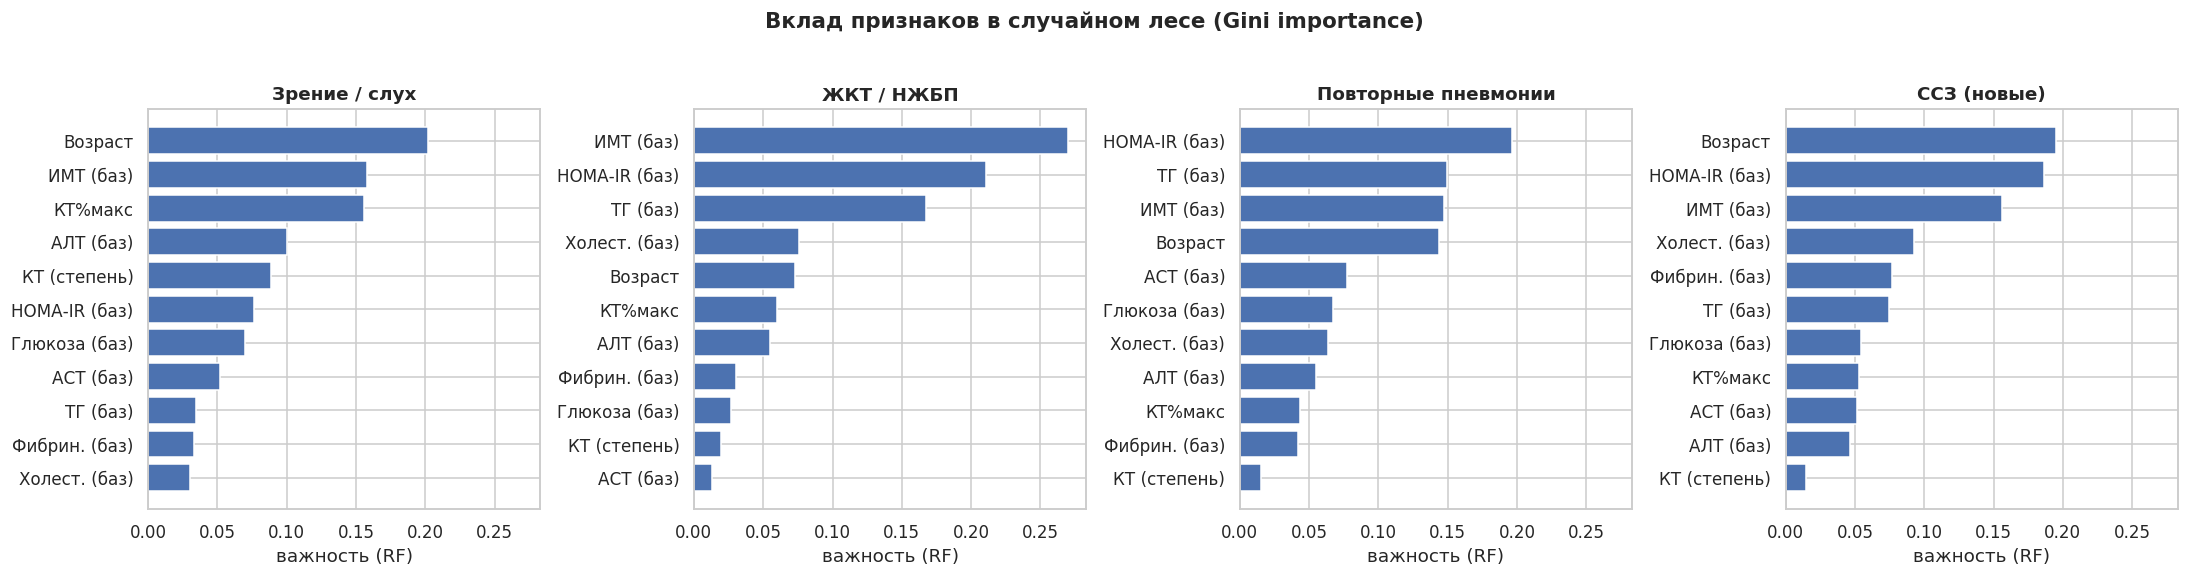

In [12]:
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
importances = {}
for cn in FREQUENT:
    y = comp[cn]
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced'))
    rf = RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=20,
                                class_weight='balanced', random_state=RANDOM_STATE)
    a_lr = cross_val_score(lr, X, y, cv=skf, scoring='roc_auc')
    a_rf = cross_val_score(rf, X, y, cv=skf, scoring='roc_auc')
    cv_rows.append({'Осложнение': cn, 'событий': int(y.sum()),
                    'AUC логистич.': f'{a_lr.mean():.3f} ± {a_lr.std():.3f}',
                    'AUC случ. лес': f'{a_rf.mean():.3f} ± {a_rf.std():.3f}'})
    rf.fit(X, y)
    importances[cn] = pd.Series(rf.feature_importances_, index=X.columns)
display(pd.DataFrame(cv_rows).set_index('Осложнение'))

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
for ax, cn in zip(axes, FREQUENT):
    imp = importances[cn].sort_values()
    colors = ['#4C72B0'] * len(imp)
    ax.barh(imp.index, imp.values, color=colors)
    ax.set_title(f'{cn}', fontweight='bold'); ax.set_xlabel('важность (RF)')
fig.suptitle('Вклад признаков в случайном лесе (Gini importance)', y=1.04, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Как читать этап 3.** Обе модели дают близкие AUC (случайный лес чуть выше на нелинейных связях,
например для ЖКТ/НЖБП). Основные предикторы поздних осложнений уже в остром периоде — **тяжесть КТ**,
**возраст** и метаболический фон (**ИМТ, НОМА-IR, ТГ**). То есть пациенты с исходно неблагоприятным
метаболизмом и более тяжёлым поражением лёгких формируют группу риска отсроченных осложнений.

---
# Этап 4. Метаболизм и КТ vs осложнения — по каждому штамму отдельно

Финальный этап отвечает на прямой вопрос руководителя: связь метаболических признаков **острого периода**
и **КТ** с осложнениями **раздельно для Ухани, Дельты и Омикрона**. Для каждого штамма строим карту
ранговых корреляций «признак ↔ осложнение». Осложнения с числом событий < 8 в данном штамме исключаются
как статистически ненадёжные (пустые клетки). Внутриштаммовые оценки поисковые (малые подвыборки),
поэтому отмечаем связи с сырым p<0.05 и трактуем как гипотезы.

## 4.1 Карты связей по штаммам

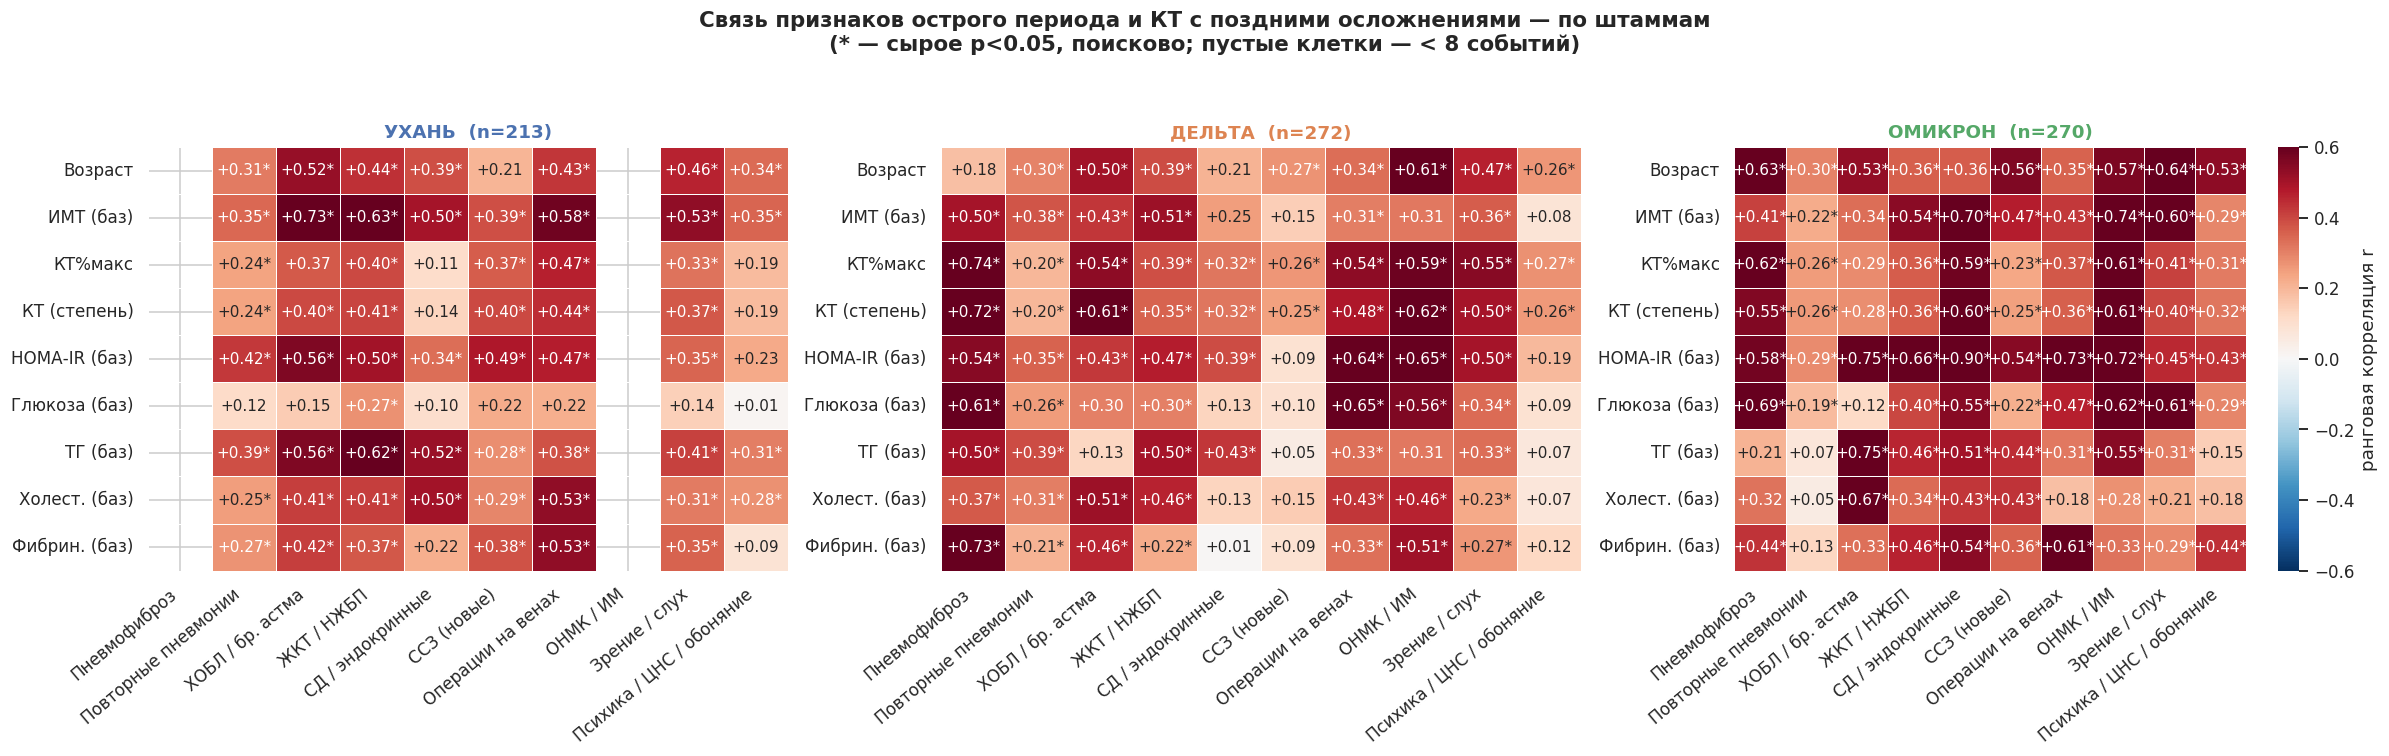

In [13]:
FEATS = ['Возраст', 'ИМТ (баз)', 'КТ%макс', 'КТ (степень)', 'НОМА-IR (баз)',
         'Глюкоза (баз)', 'ТГ (баз)', 'Холест. (баз)', 'Фибрин. (баз)']
strain_R = {}
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
for ax, s in zip(axes, STRAINS):
    mask = (G.Штамм == s).values
    Rs = pd.DataFrame(index=FEATS, columns=comp_names, dtype=float)
    As = pd.DataFrame(index=FEATS, columns=comp_names, dtype=object)
    for f in FEATS:
        for cn in comp_names:
            r, p, na = rank_biserial(X[f][mask], comp[cn].values[mask])
            Rs.loc[f, cn] = r
            As.loc[f, cn] = '' if pd.isna(r) else f'{r:+.2f}' + ('*' if (not pd.isna(p) and p < 0.05) else '')
    strain_R[s] = Rs
    sns.heatmap(Rs.astype(float), annot=As.values, fmt='', cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
                linewidths=0.5, cbar=(s == STRAINS[-1]), ax=ax,
                cbar_kws={'label': 'ранговая корреляция r'})
    ax.set_title(f'{s}  (n={int(mask.sum())})', fontweight='bold', color=STRAIN_COLORS[s])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle('Связь признаков острого периода и КТ с поздними осложнениями — по штаммам\n'
             '(* — сырое p<0.05, поисково; пустые клетки — < 8 событий)', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4.2 Сводка устойчивых внутриштаммовых связей

In [14]:
srows = []
for s in STRAINS:
    mask = (G.Штамм == s).values
    for f in FEATS:
        for cn in comp_names:
            r, p, na = rank_biserial(X[f][mask], comp[cn].values[mask])
            if not pd.isna(p) and p < 0.05 and abs(r) >= 0.20:
                srows.append({'Штамм': s, 'Признак': f, 'Осложнение': cn, 'r': r, 'p': p, 'событий': na})
srowsdf = pd.DataFrame(srows).sort_values(['Штамм', 'p'])
print('Внутриштаммовые связи с p<0.05 и |r|≥0.20 (поисковые, без FDR по малым подвыборкам):')
display(srowsdf.round(3).reset_index(drop=True))

Внутриштаммовые связи с p<0.05 и |r|≥0.20 (поисковые, без FDR по малым подвыборкам):


,Штамм,Признак,Осложнение,r,p,событий
0,ДЕЛЬТА,КТ%макс,Зрение / слух,0.547,0.000,72
1,ДЕЛЬТА,ИМТ (баз),ЖКТ / НЖБП,0.514,0.000,78
2,ДЕЛЬТА,КТ (степень),Зрение / слух,0.501,0.000,72
3,ДЕЛЬТА,ТГ (баз),ЖКТ / НЖБП,0.497,0.000,78
4,ДЕЛЬТА,НОМА-IR (баз),Зрение / слух,0.497,0.000,72
...,...,...,...,...,...,...
190,УХАНЬ,Холест. (баз),Психика / ЦНС / обоняние,0.276,0.023,26
191,УХАНЬ,НОМА-IR (баз),СД / эндокринные,0.337,0.042,13
192,УХАНЬ,КТ (степень),ХОБЛ / бр. астма,0.398,0.045,8
193,УХАНЬ,Фибрин. (баз),ХОБЛ / бр. астма,0.416,0.046,8


## 4.3 Что влияло на каждое осложнение при разных штаммах — случайный лес

Для каждого штамма **отдельно** обучаем случайный лес на признаках острого периода и КТ и оцениваем вклад
каждого признака (Gini importance) в каждое осложнение. Рассматриваем только осложнения с **≥ 20 событиями**
в данном штамме; в заголовке столбца — число событий и качество модели (AUC на 3-блочной кросс-валидации):
чем ближе AUC к 0.5, тем менее надёжен вклад признаков в этой ячейке.

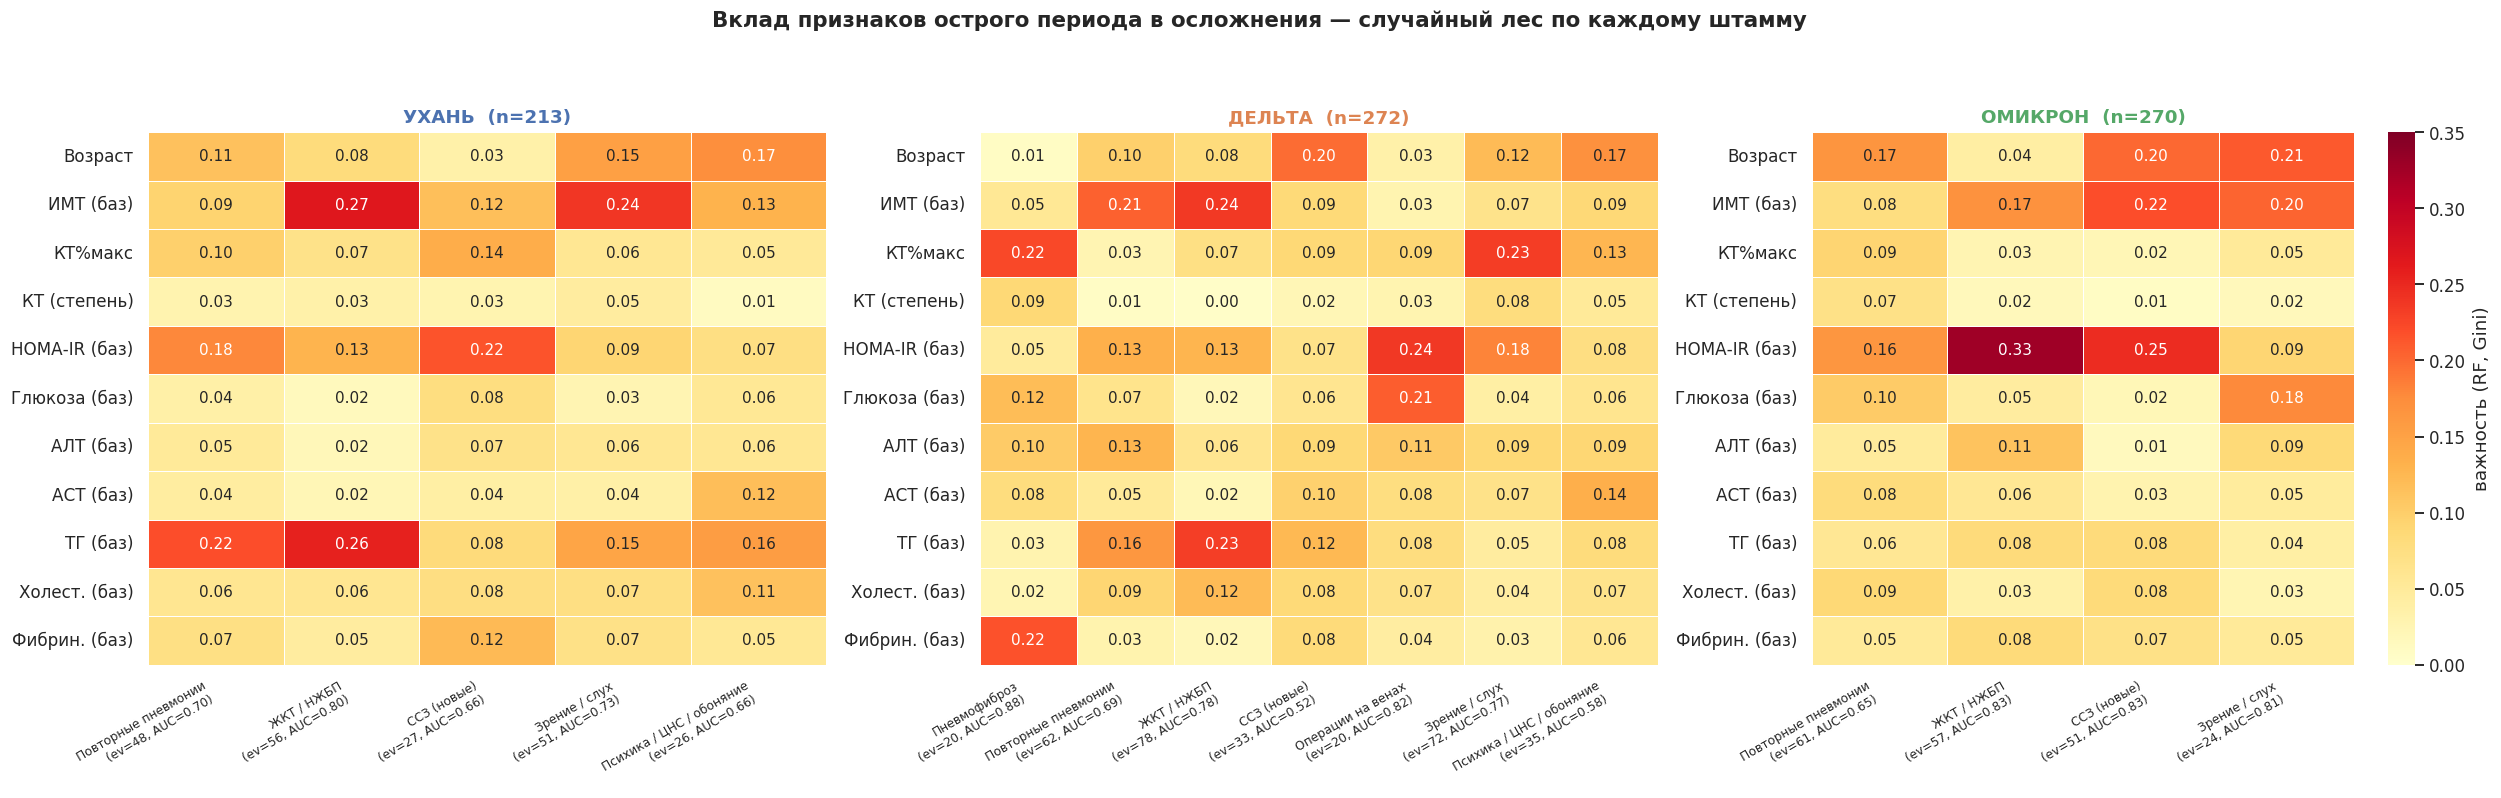

Ведущие факторы по данным случайного леса (по каждому штамму):


1-й фактор            2-й фактор
Штамм   Осложнение                                                          
УХАНЬ   Повторные пневмонии            ТГ (баз) (0.22)  НОМА-IR (баз) (0.18)
        ЖКТ / НЖБП                    ИМТ (баз) (0.27)       ТГ (баз) (0.26)
        ССЗ (новые)               НОМА-IR (баз) (0.22)        КТ%макс (0.14)
        Зрение / слух                 ИМТ (баз) (0.24)        Возраст (0.15)
        Психика / ЦНС / обоняние        Возраст (0.17)       ТГ (баз) (0.16)
ДЕЛЬТА  Пневмофиброз                    КТ%макс (0.22)  Фибрин. (баз) (0.22)
        Повторные пневмонии           ИМТ (баз) (0.21)       ТГ (баз) (0.16)
        ЖКТ / НЖБП                    ИМТ (баз) (0.24)       ТГ (баз) (0.23)
        ССЗ (новые)                     Возраст (0.20)       ТГ (баз) (0.12)
        Операции на венах         НОМА-IR (баз) (0.24)  Глюкоза (баз) (0.21)
        Зрение / слух                   КТ%макс (0.23)  НОМА-IR (баз) (0.18)
        Психика / ЦНС / обоняние        Возраст (0.17)      АСТ (баз) (0.14)
ОМИКРОН Повторные пневмонии             Возраст (0.17)  НОМА-IR (баз) (0.16)
        ЖКТ / НЖБП                НОМА-IR (баз) (0.33)      ИМТ (баз) (0.17)
        ССЗ (новые)               НОМА-IR (баз) (0.25)      ИМТ (баз) (0.22)
        Зрение / слух                   Возраст (0.21)      ИМТ (баз) (0.20)

In [15]:
RF_THRESH = 20
fig, axes = plt.subplots(1, 3, figsize=(23, 6.8))
rf_imp_store = {}
for ax, s in zip(axes, STRAINS):
    mask = (G.Штамм == s).values
    Xs = X[mask]
    cols_ok = [cn for cn in comp_names if int(comp[cn].values[mask].sum()) >= RF_THRESH]
    IMP = pd.DataFrame(index=X.columns, dtype=float)
    headers = []
    for cn in cols_ok:
        y = comp[cn].values[mask]
        rf = RandomForestClassifier(n_estimators=400, max_depth=3, min_samples_leaf=15,
                                    class_weight='balanced', random_state=RANDOM_STATE)
        try:
            auc = cross_val_score(rf, Xs, y, scoring='roc_auc',
                                  cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)).mean()
        except Exception:
            auc = np.nan
        rf.fit(Xs, y)
        IMP[cn] = rf.feature_importances_
        headers.append(f'{cn}\n(ev={int(y.sum())}, AUC={auc:.2f})')
    rf_imp_store[s] = IMP
    sns.heatmap(IMP.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=0.35,
                linewidths=0.5, cbar=(s == STRAINS[-1]), ax=ax,
                cbar_kws={'label': 'важность (RF, Gini)'})
    ax.set_xticklabels(headers, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'{s}  (n={int(mask.sum())})', fontweight='bold', color=STRAIN_COLORS[s])
fig.suptitle('Вклад признаков острого периода в осложнения — случайный лес по каждому штамму', y=1.06,
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# краткая сводка: главный драйвер каждой пары «штамм × осложнение»
top_rows = []
for s in STRAINS:
    IMP = rf_imp_store[s]
    for cn in IMP.columns:
        srt = IMP[cn].sort_values(ascending=False)
        top_rows.append({'Штамм': s, 'Осложнение': cn,
                         '1-й фактор': f'{srt.index[0]} ({srt.iloc[0]:.2f})',
                         '2-й фактор': f'{srt.index[1]} ({srt.iloc[1]:.2f})'})
print('Ведущие факторы по данным случайного леса (по каждому штамму):')
display(pd.DataFrame(top_rows).set_index(['Штамм', 'Осложнение']))

**Как читать этап 4.** Ядро связей воспроизводится во всех штаммах: **тяжесть КТ**, **возраст** и
метаболический фон (**ИМТ, НОМА-IR, ТГ**) сцеплены с поздними осложнениями независимо от варианта вируса.
Различия между штаммами носят в основном количественный характер и частично объясняются составом групп
(возраст, вакцинация, исходная тяжесть), а не самим геновариантом.

---
# Выводы

**1. Динамика метаболизма за 24 месяца двунаправленная.**
Маркеры острого периода — **АЛТ, АСТ, фибриноген** и (у Ухани/Дельты) **глюкоза** — через 24 месяца
снижаются, отражая восстановление. Напротив, **НОМА-IR** (инсулинорезистентность) и **ТГ** значимо
**растут** во всех штаммах — формируется отсроченный метаболический сдвиг. ИМТ и холестерин
меняются слабо.

**2. Штаммовые различия.**
Прирост НОМА-IR, ТГ и глюкозы наименее выражен у **Омикрона** (Краскел–Уоллис и медианная регрессия с
поправкой на КТ и возраст). Ухань и Дельта дают более выраженный отсроченный метаболический след, что
согласуется с их большей исходной тяжестью.

**3. Метаболический сдвиг сопряжён с осложнениями.**
Рост **ТГ** и **НОМА-IR** за 24 месяца связан почти со всеми поздними осложнениями; для сосудистых
исходов (ССЗ, ОНМК/ИМ, операции на венах) добавляется рост **холестерина** и **глюкозы**. Это связи на
одном временном интервале (сопряжённость, не доказанная причинность).

**4. Прогноз по острому периоду.**
Логистическая регрессия и случайный лес согласованно выделяют предикторы поздних осложнений уже в
остром периоде: **тяжесть КТ, возраст, ИМТ, НОМА-IR, ТГ** (AUC ≈ 0.67–0.81 в зависимости от исхода).
Случайный лес немного точнее на нелинейных связях (ЖКТ/НЖБП).

**5. Устойчивость по штаммам.**
Раздельный анализ Ухани, Дельты и Омикрона (в т.ч. **случайный лес по каждому штамму**) показывает одно
и то же ядро факторов риска (КТ, возраст, метаболический фон); различия между штаммами преимущественно
количественные и частично объясняются составом групп. Отдельные штамм-специфичные акценты: у Дельты
пневмофиброз сильнее всего определяется тяжестью КТ и фибриногеном, у Омикрона ССЗ и ЖКТ — исходным
НОМА-IR и ИМТ (при этом часть внутриштаммовых моделей имеет AUC около 0.5 и ненадёжна из-за малого
числа событий).

**Практический вывод.** Пациенты, перенёсшие COVID-19 (особенно Ухань/Дельта) с тяжёлым поражением
лёгких и исходно неблагоприятным метаболическим профилем, через 24 месяца имеют нарастающую
инсулинорезистентность и дислипидемию и составляют группу риска поздних кардиометаболических и
других осложнений — им показан метаболический мониторинг (НОМА-IR, липиды, глюкоза) в отдалённом периоде.
